This is a **core concept** in data analysis—and you’re very close to mastering it. Let’s break it down in a **simple, structured, beginner-friendly way** so it really “clicks.”

---

# 🧠 The Big Idea (in plain English)

👉 Analysts **never trust just one number (like mean)**
👉 They always look at **3 things together**:

1. **Center** → What is typical?
2. **Variation** → How consistent is it?
3. **Shape (distribution)** → Why does it look like this?

---

# 📊 Think of it like this (simple analogy)

Imagine two hospital wards:

* Both have **average stay = 5 days**

But:

* Ward A → everyone stays **4–6 days** ✅
* Ward B → some stay **2 days, some 20 days** ❗

👉 Same average
👉 Completely different reality

💡 That’s why we need **center + variation + shape together**

---

# 🔍 1️⃣ CENTER → “What is typical?”

### Tools:

* **Mean** (average)
* **Median** (middle value)
* **Mode** (most common)

### How analysts think:

| Situation                  | What to use |
| -------------------------- | ----------- |
| Data is normal (balanced)  | Mean        |
| Data has outliers / skewed | Median      |

### 🚨 Key insight:

👉 If **mean ≠ median**, something is going on (skew/outliers)

---

# 📈 2️⃣ VARIATION → “How consistent is it?”

### Tools:

* Range
* Variance
* Standard deviation (SD)

### Interpretation:

| Variation | Meaning               |
| --------- | --------------------- |
| Low SD    | Stable, predictable ✅ |
| High SD   | Unstable, risky ❗     |

### 🏥 Example:

* BP readings all around 120 → stable
* BP jumps 90 → 180 → unstable

👉 Same mean possible, different risk!

---

# 📐 3️⃣ SHAPE → “What’s the hidden story?”

This is the **most powerful part**.

---

## 🔵 Normal (Symmetrical)

* Bell-shaped curve
* Mean ≈ Median

👉 Action:

* Use **mean**
* Use **t-test / linear regression**

---

## 🔴 Right-Skewed (common in healthcare)

* Long tail on the right
* Few very high values

🏥 Example:

* Hospital cost
* Length of stay

👉 Action:

* Use **median**
* Use **non-parametric tests**
* Consider **log transformation**

---

## 🔵 Left-Skewed

* Few very low values

👉 Action:

* Investigate low outliers

---

## 🟣 Bimodal (VERY important)

* Two peaks

🏥 Example:

* Children + adults mixed

👉 Action:

* ❗ **DO NOT summarize together**
* Split into groups

---

## 🟠 Multimodal

* Many peaks

👉 Action:

* Segment data (age, hospital, condition)

---

## ⚠️ With Outliers

* Extreme values far away

👉 Action:

* Validate them
* Use median or robust methods

---

# 🔗 How Analysts Combine All 3

### Step-by-step workflow:

1. **Look at center**

   * Mean vs median

2. **Check variation**

   * SD high or low?

3. **Visualize shape**

   * Histogram / boxplot

4. **Then decide:**

   * Which statistic?
   * Which test?
   * Which model?

---

# 🏥 Real Clinical Example (Simplified)

## Infection Rates

| Metric    | Ward A | Ward B    |
| --------- | ------ | --------- |
| Mean      | 2.1%   | 2.1%      |
| Variation | Low    | High ❗    |
| Shape     | Normal | Bimodal ❗ |

---

### 🧠 Analyst thinking:

👉 “Means are same… but”

* Ward A → stable ✅
* Ward B → unstable + two patterns ❗

👉 Action:

* Investigate **specific months or staff**
* Not treat wards as equal

---

# 💊 Another Example (Pain Scores)

| Metric | Protocol A | Protocol B     |
| ------ | ---------- | -------------- |
| Median | 6          | 6              |
| SD     | Low        | High ❗         |
| Shape  | Tight      | Right-skewed ❗ |

---

### 🧠 Insight:

👉 Protocol B has:

* Some patients with **extreme pain (9–10)**
* Hidden subgroup ❗

👉 Action:

* Identify those patients
* Improve treatment

---

# ⚠️ Common Beginner Mistakes

❌ Only looking at mean
❌ Ignoring variability
❌ Assuming normal distribution
❌ Not plotting data
❌ Mixing different groups

---

# 🎯 Final Cheat Rule (VERY IMPORTANT)

👉 Before ANY analysis, always ask:

1. Is data **normal or skewed?**
2. Is variability **low or high?**
3. Are there **multiple groups?**

---

# 🚀 One-Line Summary

👉 **Mean tells you “what”**
👉 **Variation tells you “how stable”**
👉 **Distribution tells you “why”**

---

If you want, I can turn this into:
✅ a **1-page exam cheat sheet**
✅ or give you **practice questions (with answers)** to test your understanding


In [1]:


# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

# Reproducibility
RNG = np.random.default_rng(42)
random.seed(42)

pd.set_option('display.max_columns', 50)
sns.set(style="whitegrid")
print('Setup complete. Running in Colab:', IN_COLAB)


Setup complete. Running in Colab: True


The following cell simulates a realistic, clinically plausible patient vital-signs dataset by generating demographic attributes, assigning patients to wards, creating timestamped vital-sign measurements over multiple days, and adding natural variability, missing values, and occasional outliers to mirror real-world hospital data for analysis and practice.

In [2]:
# Function to simulate vital signs dataset
def simulate_vitals(n_patients=120, days=4, measurements_per_day=3, start_date=datetime(2025,11,20,6,0)):
    patient_ids = [f"P{1000+i}" for i in range(n_patients)]
    records = []
    wards = ['Med', 'Surg', 'ICU']
    for pid in patient_ids:
        age = int(RNG.normal(58, 16)) if RNG.random() > 0.05 else int(RNG.normal(35, 8))
        sex = 'M' if RNG.random() < 0.53 else 'F'
        ward = RNG.choice(wards, p=[0.55, 0.35, 0.10])
        baseline_hr = int(max(40, RNG.normal(78, 12)))
        baseline_sbp = int(max(80, RNG.normal(125, 14)))
        baseline_dbp = int(max(40, RNG.normal(78, 9)))
        baseline_spo2 = int(min(100, max(85, RNG.normal(97, 2))))
        baseline_temp = round(RNG.normal(36.7, 0.4), 1)
        for d in range(days):
            for m in range(measurements_per_day):
                ts = start_date + timedelta(days=d, hours=m*6) + timedelta(minutes=int(RNG.normal(0,30)))
                hr = int(np.clip(RNG.normal(baseline_hr, 8), 30, 200))
                sbp = int(np.clip(RNG.normal(baseline_sbp, 10), 60, 260))
                dbp = int(np.clip(RNG.normal(baseline_dbp, 6), 30, 160))
                spo2 = int(np.clip(RNG.normal(baseline_spo2, 1.8), 70, 100))
                temp_c = round(np.clip(RNG.normal(baseline_temp, 0.25), 34.0, 41.0), 1)
                resp_rate = int(np.clip(RNG.normal(16, 3), 6, 40))
                # inject missingness
                if RNG.random() < 0.05:
                    hr = np.nan
                if RNG.random() < 0.04:
                    sbp = np.nan
                    dbp = np.nan
                if RNG.random() < 0.03:
                    spo2 = np.nan
                # inject rare outliers
                if RNG.random() < 0.01:
                    hr = int(RNG.normal(160, 8))
                if RNG.random() < 0.005:
                    temp_c = round(RNG.normal(40.2, 0.6), 1)
                records.append({
                    'patient_id': pid,
                    'age': age,
                    'sex': sex,
                    'ward': ward,
                    'timestamp': ts,
                    'hr': hr,
                    'sbp': sbp,
                    'dbp': dbp,
                    'spo2': spo2,
                    'temp_c': temp_c,
                    'resp_rate': resp_rate
                })
    df = pd.DataFrame.from_records(records)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

# Create dataset
df = simulate_vitals(n_patients=120, days=4, measurements_per_day=3)
df.head()

,patient_id,age,sex,ward,timestamp,hr,sbp,dbp,spo2,temp_c,resp_rate
0,P1014,61,M,Med,2025-11-20 06:01:00,71.0,126.0,78.0,98.0,37.5,14
1,P1050,65,M,Med,2025-11-21 18:25:00,65.0,115.0,92.0,98.0,36.5,20
2,P1045,30,M,Med,2025-11-22 18:42:00,58.0,120.0,74.0,99.0,36.9,11
3,P1005,52,F,Med,2025-11-21 17:48:00,75.0,112.0,89.0,99.0,37.6,12
4,P1052,48,M,ICU,2025-11-21 12:52:00,68.0,115.0,75.0,96.0,36.8,13


## Step 1: Inspect the data

The code cell below shows basic inspection commands. This code provides a quick structural and statistical overview of the dataset by displaying its dimensions, data types for each column, and descriptive statistics for the first set of variables—helping you verify data integrity before performing deeper analysis.

In [3]:
print('Rows, Columns:', df.shape)
print(df.dtypes)
df.describe(include='all').T.head(12)

Rows, Columns: (1440, 11)
patient_id            object
age                    int64
sex                   object
ward                  object
timestamp     datetime64[ns]
hr                   float64
sbp                  float64
dbp                  float64
spo2                 float64
temp_c               float64
resp_rate              int64
dtype: object


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,1440,120,P1014,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1440.0,NaN,NaN,NaN,56.125,17.0,44.5,55.5,67.0,99.0,17.31187
sex,1440,2,M,732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ward,1440,3,Med,828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,1440,NaN,NaN,NaN,2025-11-21 23:59:29.916666624,2025-11-20 04:27:00,2025-11-21 02:16:00,2025-11-22 00:09:30,2025-11-22 21:50:15,2025-11-23 19:27:00,NaN
hr,1375.0,NaN,NaN,NaN,77.959273,37.0,68.0,77.0,87.0,173.0,16.149991
sbp,1385.0,NaN,NaN,NaN,123.279422,70.0,111.0,123.0,135.0,175.0,17.881653
dbp,1385.0,NaN,NaN,NaN,78.331408,40.0,71.0,78.0,86.0,109.0,10.718309
spo2,1395.0,NaN,NaN,NaN,95.976344,87.0,94.0,96.0,98.0,100.0,2.369131
temp_c,1440.0,NaN,NaN,NaN,36.732986,35.4,36.4,36.7,37.0,41.0,0.532478


## Step 2: Basic descriptive statistics for continuous vitals

Run the following code cell to isolate all vital-sign variables and generate their descriptive statistics. This will allow you to quickly assess central tendencies and variability for each clinical measurement.

In [4]:
vital_cols = ['hr', 'sbp', 'dbp', 'spo2', 'temp_c', 'resp_rate']
df[vital_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
hr,1375.0,77.959273,16.149991,37.0,68.0,77.0,87.0,173.0
sbp,1385.0,123.279422,17.881653,70.0,111.0,123.0,135.0,175.0
dbp,1385.0,78.331408,10.718309,40.0,71.0,78.0,86.0,109.0
spo2,1395.0,95.976344,2.369131,87.0,94.0,96.0,98.0,100.0
temp_c,1440.0,36.732986,0.532478,35.4,36.4,36.7,37.0,41.0
resp_rate,1440.0,15.504861,2.963991,6.0,13.0,15.0,18.0,28.0


## Step 3: Visualize distributions

The following cells show common plots. Run this code cell to visualize the distribution of each vital-sign variable using histograms with density curves. This will help you quickly identify patterns, ranges, skewness, and potential outliers across the clinical measurements.

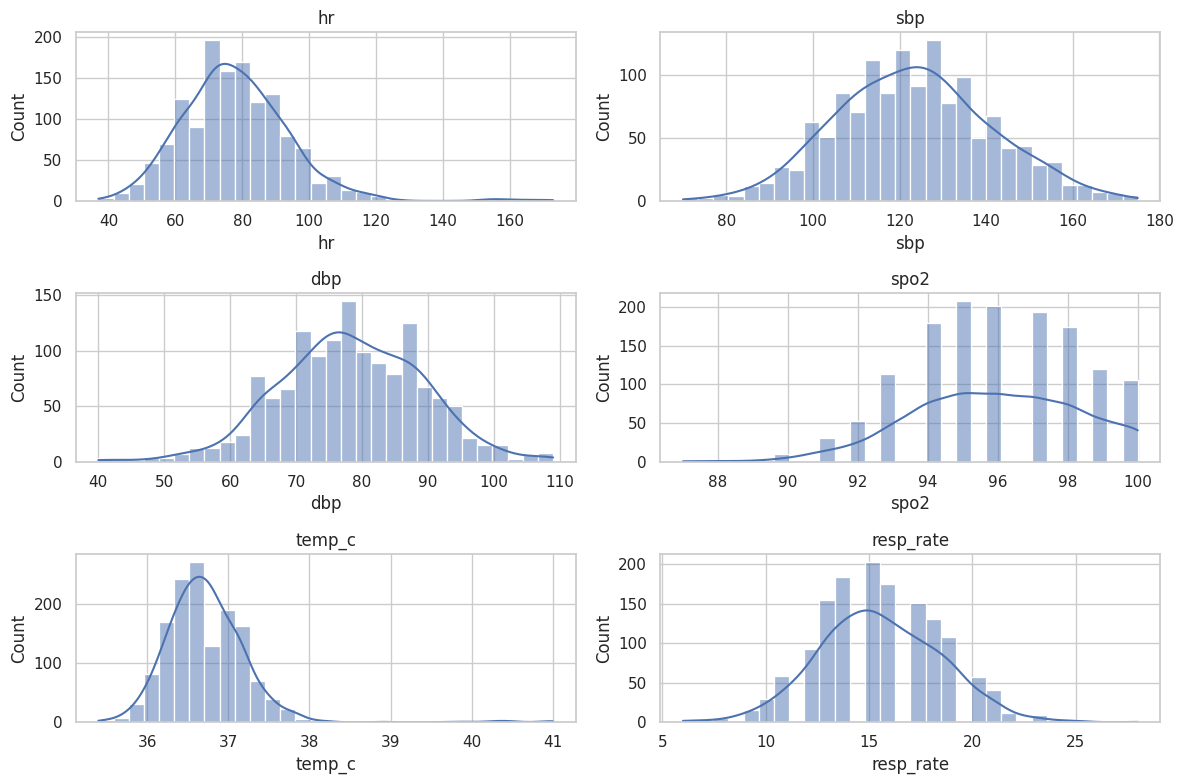

In [5]:
# Histograms
plt.figure(figsize=(12, 8))
for i, col in enumerate(vital_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(col)
plt.tight_layout()

Run this code cell to create boxplots of selected vital signs across different hospital wards to compare their distributions. This will make it easier to spot differences, variability, and potential outliers between patient groups.

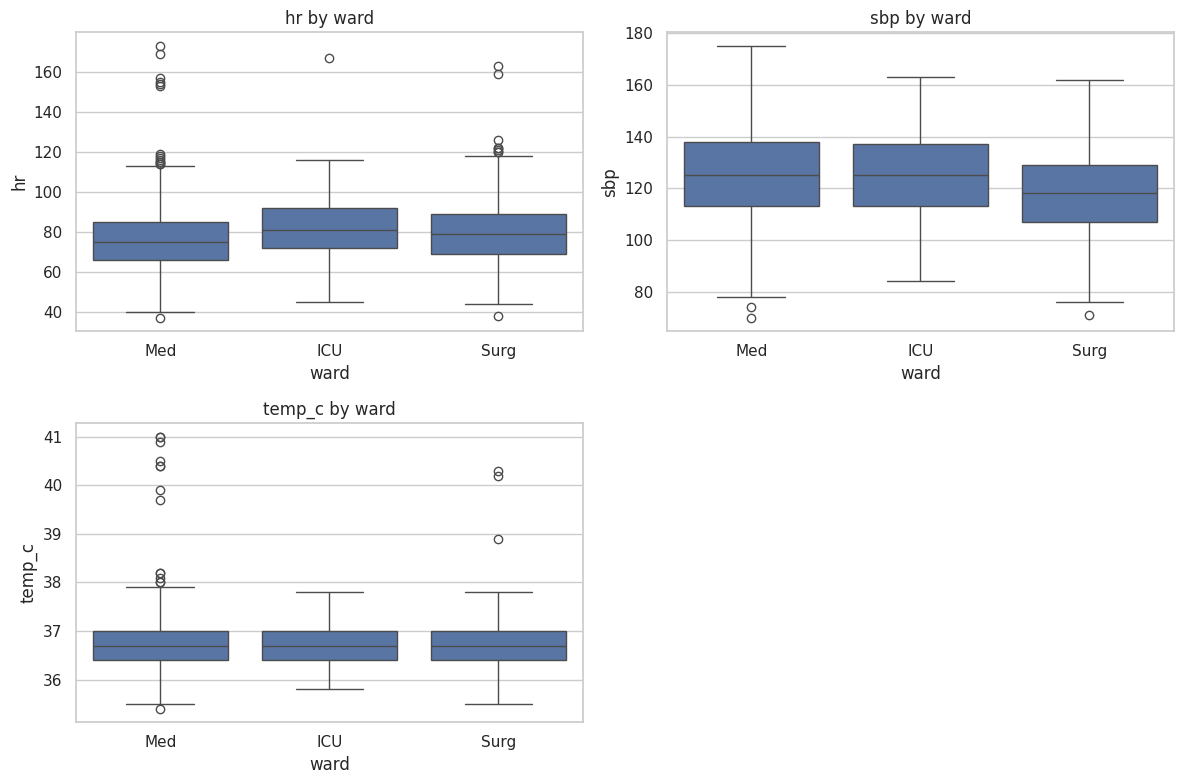

In [6]:
# Boxplots by ward
plt.figure(figsize=(12, 8))
for i, col in enumerate(['hr', 'sbp', 'temp_c']):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='ward', y=col, data=df)
    plt.title(f'{col} by ward')
plt.tight_layout()

## Step 4: Missing data handling

Identify missing patterns and forward/back-fill example. Run this code cell to calculate and print the percentage of missing values in each column. This will help you assess data completeness and identify variables that may require cleaning or imputation.

In [7]:
missing_pct = df.isna().mean().round(3) * 100
print('Missing % per column:\n', missing_pct)

Missing % per column:
 patient_id    0.0
age           0.0
sex           0.0
ward          0.0
timestamp     0.0
hr            4.5
sbp           3.8
dbp           3.8
spo2          3.1
temp_c        0.0
resp_rate     0.0
dtype: float64


Thi code cell fills missing vital-sign values within each patient’s timeline using forward-fill and backward-fill methods, then compares missing-value counts before and after imputation to verify that gaps have been successfully handled.

In [8]:
df_sorted = df.sort_values(['patient_id', 'timestamp']).copy()
df_ffill = df_sorted.groupby('patient_id').apply(lambda x: x.ffill().bfill(), include_groups=False).reset_index(drop=True)
print('Before missing counts:\n', df.isna().sum())
print('After ffill/bfill counts:\n', df_ffill.isna().sum())

Before missing counts:
 patient_id     0
age            0
sex            0
ward           0
timestamp      0
hr            65
sbp           55
dbp           55
spo2          45
temp_c         0
resp_rate      0
dtype: int64
After ffill/bfill counts:
 age          0
sex          0
ward         0
timestamp    0
hr           0
sbp          0
dbp          0
spo2         0
temp_c       0
resp_rate    0
dtype: int64


## Step 5: Outlier detection

IQR-based detection example.

Run the code cell to define a function to identify outliers using the Interquartile Range (IQR) method and apply it to heart-rate data. This allows you to detect unusually low or high HR values that may need investigation or cleaning.

In [10]:
def iqr_outliers(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return series[(series < lower) | (series > upper)]

hr_outliers = iqr_outliers(df['hr'].dropna())
print('HR outliers count:', len(hr_outliers))

HR outliers count: 25


## Step 6: Group summaries (by ward, age group, sex)

Aggregated summaries example.

Run the code cell to group patients by ward and age category, then compute median values and IQRs for key vital signs—along with patient counts—to summarize how clinical measurements vary across demographic and clinical subgroups.

In [11]:
bins = [0, 30, 50, 65, 120]
labels = ['<30', '30-49', '50-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

agg = df.groupby(['ward', 'age_group']).agg(
    hr_median=('hr', 'median'),
    hr_iqr=('hr', lambda x: x.quantile(0.75)-x.quantile(0.25)),
    sbp_median=('sbp', 'median'),
    sbp_iqr=('sbp', lambda x: x.quantile(0.75)-x.quantile(0.25)),
    count=('patient_id', 'count')
).reset_index()
agg.head(12)

/tmp/ipykernel_16611/2224792199.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['ward', 'age_group']).agg(


,ward,age_group,hr_median,hr_iqr,sbp_median,sbp_iqr,count
0,ICU,<30,96.0,10.50,112.0,26.50,12
1,ICU,30-49,76.5,15.25,132.5,26.75,48
2,ICU,50-64,83.0,16.00,137.0,16.00,48
3,ICU,65+,78.0,26.00,117.5,18.25,72
4,Med,<30,70.5,31.75,125.0,25.50,72
5,Med,30-49,73.0,19.50,127.0,25.00,180
6,Med,50-64,78.0,16.50,124.0,28.00,360
7,Med,65+,73.0,20.00,124.0,20.00,216
8,Surg,<30,67.0,22.00,99.0,38.00,24
9,Surg,30-49,78.0,21.00,112.0,21.00,120


## Step 7: Patient-level summaries and variability

Per-patient aggregations.

Run the code cell to create a patient-level summary by calculating the number of measurements and key statistical metrics (mean, standard deviation, and maximum values) for each vital sign. This will enable you to understand individual patient patterns and variability over time.

In [12]:
patient_summary = df.groupby('patient_id').agg(
    n_measurements=('hr', 'count'),
    hr_mean=('hr', 'mean'),
    hr_std=('hr', 'std'),
    sbp_mean=('sbp', 'mean'),
    sbp_std=('sbp', 'std'),
    spo2_mean=('spo2', 'mean'),
    temp_max=('temp_c', 'max')
).reset_index()
patient_summary.head()

,patient_id,n_measurements,hr_mean,hr_std,sbp_mean,sbp_std,spo2_mean,temp_max
0,P1000,11,55.000000,5.603570,106.818182,7.277612,95.000000,36.9
1,P1001,12,79.833333,7.056053,148.083333,10.396313,96.750000,36.9
2,P1002,12,59.250000,9.274844,138.250000,7.085517,96.363636,36.5
3,P1003,11,100.818182,8.818369,129.000000,8.301150,97.200000,36.5
4,P1004,11,94.272727,25.791824,119.833333,10.052890,93.750000,36.7


## Step 8: Relationships and correlations

Scatter and correlation heatmap.

Run the code cell to visualize relationships between vital signs by plotting systolic versus diastolic blood pressure across wards and generating a correlation heatmap. This allows you to explore how different clinical measurements relate to one another.

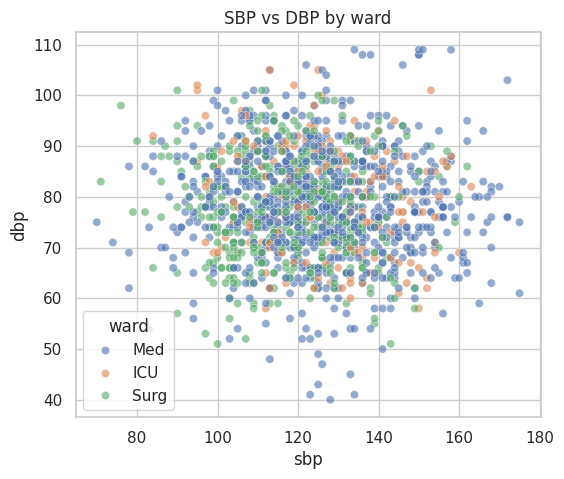

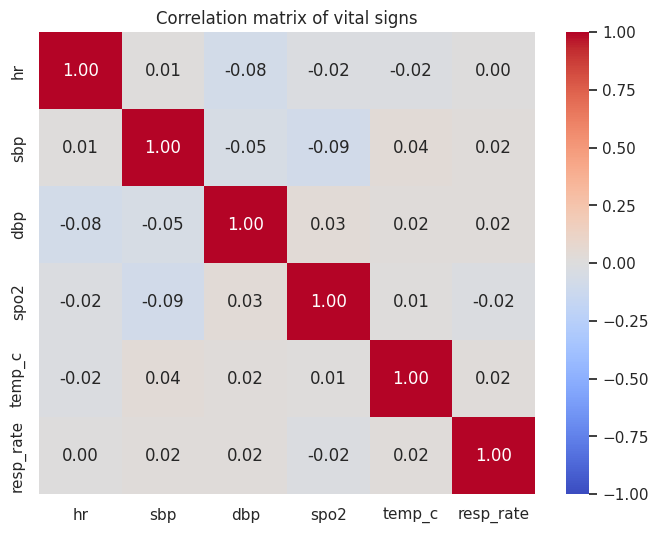

In [13]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df.dropna(subset=['sbp','dbp']), x='sbp', y='dbp', hue='ward', alpha=0.6)
plt.title('SBP vs DBP by ward')
plt.show()

plt.figure(figsize=(8,6))
corr = df[vital_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix of vital signs')
plt.show()

## Step 9: Reporting: assemble clinician-ready summary

Ward-level reporting example.

Run the code cell to generate a concise, ward-level summary report by computing record counts and key statistics for multiple vital signs. This provides a quick snapshot of typical clinical values and variability within each hospital ward.

In [14]:
ward_report = df.groupby('ward').agg(
    n_records=('patient_id', 'count'),
    hr_median=('hr', 'median'),
    hr_iqr=('hr', lambda x: x.quantile(0.75)-x.quantile(0.25)),
    sbp_median=('sbp', 'median'),
    spo2_median=('spo2', 'median'),
    temp_mean=('temp_c', 'mean')
).reset_index()
ward_report

,ward,n_records,hr_median,hr_iqr,sbp_median,spo2_median,temp_mean
0,ICU,180,81.0,20.0,125.0,96.0,36.691667
1,Med,828,75.0,19.0,125.0,96.0,36.761957
2,Surg,432,79.0,20.0,118.0,96.0,36.694676


## Consolidated practice exercises



### Exercise 1: Inspect missingness and unique counts

In [ ]:
# your code goes here

In [15]:
print('Missing values per column:')
print(df.isna().sum())
print('\nUnique patients:', df['patient_id'].nunique())

Missing values per column:
patient_id     0
age            0
sex            0
ward           0
timestamp      0
hr            65
sbp           55
dbp           55
spo2          45
temp_c         0
resp_rate      0
age_group      0
dtype: int64

Unique patients: 120


<details> <summary>Click here for a hint</summary>

Check `df.isna().sum()` for missingness and `df['patient_id'].nunique()` for unique patient count.

</details>

<details> <summary>Click here for solution</summary>

```python
print('Missing values per column:')
print(df.isna().sum())
print('\nUnique patients:', df['patient_id'].nunique())
```

</details>

### Exercise 2: Create `describe_vitals(df, cols)` returning mean, median, std, IQR for specified columns

In [ ]:
# your code goes here

In [17]:
def describe_vitals(df, cols):
    out = {}
    for col in cols:
        s = df[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        out[col] = {
            'count': int(s.count()),
            'mean': float(s.mean()),
            'median': float(s.median()),
            'std': float(s.std()),
            'iqr': float(q3 - q1),
            'min': float(s.min()),
            'max': float(s.max())
        }
    return pd.DataFrame(out).T

describe_vitals(df, vital_cols)

,count,mean,median,std,iqr,min,max
hr,1375.0,77.959273,77.0,16.149991,19.0,37.0,173.0
sbp,1385.0,123.279422,123.0,17.881653,24.0,70.0,175.0
dbp,1385.0,78.331408,78.0,10.718309,15.0,40.0,109.0
spo2,1395.0,95.976344,96.0,2.369131,4.0,87.0,100.0
temp_c,1440.0,36.732986,36.7,0.532478,0.6,35.4,41.0
resp_rate,1440.0,15.504861,15.0,2.963991,5.0,6.0,28.0


<details> <summary>Click here for a hint</summary>

Use `.median()`, `.mean()`, `.std()`, and quantiles `.quantile(0.25)` and `.quantile(0.75)` to compute IQR.

</details>

<details> <summary>Click here for solution</summary>

```python
def describe_vitals(df, cols):
    out = {}
    for col in cols:
        s = df[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        out[col] = {
            'count': int(s.count()),
            'mean': float(s.mean()),
            'median': float(s.median()),
            'std': float(s.std()),
            'iqr': float(q3 - q1),
            'min': float(s.min()),
            'max': float(s.max())
        }
    return pd.DataFrame(out).T

describe_vitals(df, vital_cols)
```

</details>

### Exercise 3: Impute missing SBP and DBP by ward median and show counts before/after

In [ ]:
# your code goes here

In [18]:
df_imputed = df.copy()

print('Missing SBP and DBP before imputation:')
print(df_imputed[['sbp', 'dbp']].isna().sum())

for col in ['sbp', 'dbp']:
    df_imputed[col] = df_imputed[col].fillna(df_imputed.groupby('ward')[col].transform('median'))

print('\nMissing SBP and DBP after imputation:')
print(df_imputed[['sbp', 'dbp']].isna().sum())

Missing SBP and DBP before imputation:
sbp    55
dbp    55
dtype: int64

Missing SBP and DBP after imputation:
sbp    0
dbp    0
dtype: int64


<details> <summary>Click here for a hint</summary>

Use `df.groupby('ward')['sbp'].transform('median')` and fillna on the column.

</details>

<details> <summary>Click here for solution</summary>

```python
df_imputed = df.copy()
for col in ['sbp', 'dbp']:
    before = df_imputed[col].isna().sum()
    df_imputed[col] = df_imputed[col].fillna(df_imputed.groupby('ward')[col].transform('median'))
    after = df_imputed[col].isna().sum()
    print(f"{col}: before {before}, after {after}")
```

</details>

### Exercise 4: Flag rows where temperature > 39.0°C or SpO₂ < 90% and show count + head(5)

In [19]:
mask = (df['temp_c'] > 39.0) | (df['spo2'] < 90)
print('Count:', mask.sum())
df.loc[mask].head(5)

Count: 14


,patient_id,age,sex,ward,timestamp,hr,sbp,dbp,spo2,temp_c,resp_rate,age_group
178,P1111,76,M,Med,2025-11-22 12:00:00,71.0,144.0,90.0,100.0,40.4,16,65+
347,P1067,62,F,Surg,2025-11-23 05:52:00,77.0,131.0,72.0,87.0,37.3,14,50-64
362,P1101,80,M,Med,2025-11-22 11:18:00,78.0,118.0,70.0,97.0,40.5,14,65+
693,P1101,80,M,Med,2025-11-20 05:19:00,56.0,122.0,80.0,96.0,40.9,15,65+
754,P1059,17,M,ICU,2025-11-20 05:48:00,106.0,124.0,98.0,89.0,36.8,17,<30


<details> <summary>Click here for a hint</summary>

Create a boolean mask `(df['temp_c'] > 39.0) | (df['spo2'] < 90)` and use it to filter.

</details>

<details> <summary>Click here for solution</summary>

```python
mask = (df['temp_c'] > 39.0) | (df['spo2'] < 90)
print('Count:', mask.sum())
df.loc[mask].head(5)
```

</details>

### Exercise 5: Calculate Pearson correlation between heart rate and temperature and interpret strength (weak/moderate/strong)

In [ ]:
# your code goes here

<details> <summary>Click here for a hint</summary>

Use `df[['hr','temp_c']].dropna().corr().loc['hr','temp_c']`. Interpret using thresholds: |r|<0.3 weak, 0.3–0.6 moderate, >0.6 strong.

</details>

<details> <summary>Click here for solution</summary>

```python
corr_value = df[['hr','temp_c']].dropna().corr().loc['hr','temp_c']
print('Pearson correlation (HR, Temp):', round(corr_value, 3))
if abs(corr_value) < 0.3:
    print('Interpretation: weak correlation')
elif abs(corr_value) < 0.6:
    print('Interpretation: moderate correlation')
else:
    print('Interpretation: strong correlation')
```

</details>

Best practices:

Track where your data comes from and how it was measured
Use median and IQR for skewed data
Combine tables + visualizations for reporting
Keep reproducible code to recreate results